# 电影圈数据

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
import scipy
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Heiti TC']
plt.rcParams['axes.unicode_minus'] = False
from networkx.algorithms import bipartite

In [7]:
import sys
sys.path.append("..")

# 数据处理

In [3]:
df_movie = pd.read_csv("../data/movie_data.csv")
df_movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224725 entries, 0 to 224724
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   cast_id          224725 non-null  int64  
 1   cast_name        224725 non-null  object 
 2   gender           224380 non-null  object 
 3   movie_id         224725 non-null  int64  
 4   k_role           224725 non-null  object 
 5   is_main_cast     224725 non-null  object 
 6   index            224725 non-null  int64  
 7   id               224725 non-null  int64  
 8   k_title          224725 non-null  object 
 9   k_type           224725 non-null  object 
 10  k_release_date   224725 non-null  object 
 11  k_region         224725 non-null  object 
 12  k_movie_year     224725 non-null  int64  
 13  k_genres         224725 non-null  object 
 14  is_rating        224725 non-null  object 
 15  rating_num       100887 non-null  float64
 16  rating_people    224725 non-null  obje

# 数据统计

## 年度数据

In [4]:
# 按年统计每年的电影数量
df_count_by_year = df_movie.groupby('k_movie_year')['movie_id_m'].nunique().reset_index()
df_count_by_year.columns = ['year', 'movie_count']
df_count_by_year = df_count_by_year.sort_values('year')
df_count_by_year

,year,movie_count
0,1905,2
1,1909,2
2,1913,14
3,1916,1
4,1919,1
...,...,...
106,2021,1547
107,2022,1265
108,2023,1254
109,2024,1099


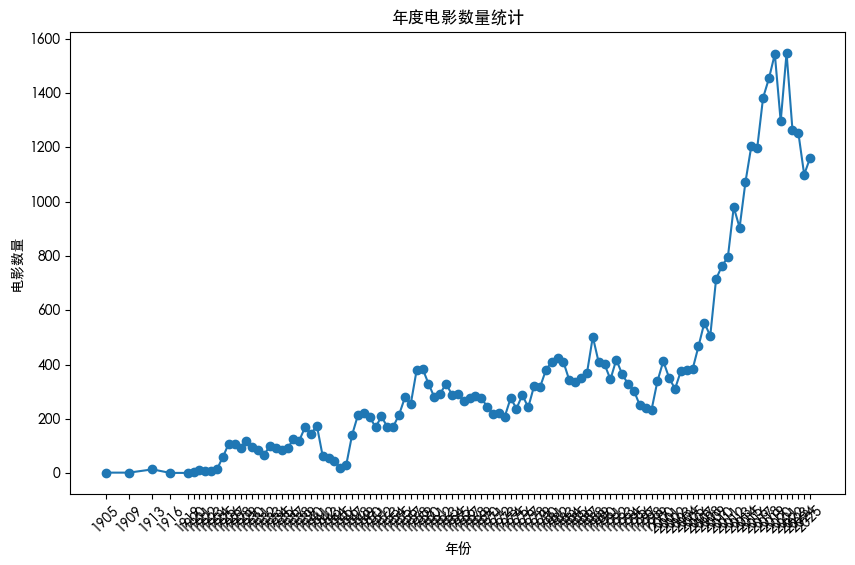

In [10]:
# 绘图
plt.figure(figsize=(10, 6))
plt.plot(df_count_by_year['year'], df_count_by_year['movie_count'], marker='o')
plt.title('年度电影数量统计')
plt.xlabel('年份')
plt.ylabel('电影数量')
plt.xticks(df_count_by_year['year'], rotation=45)
# plt.tight_layout()
plt.show()

# 图对象

In [11]:
G = nx.from_pandas_edgelist(
    df_movie,
    source='k_cast_id',
    target='movie_id_m',
    edge_attr=True,
    create_using=nx.Graph()
)
G.number_of_nodes(), G.number_of_edges()

(83402, 223085)

In [12]:
# 子图数量
len(list(nx.connected_components(G)))

2350

In [13]:
# 最大联通分支
largest_cc = max(nx.connected_components(G), key=len)
G_largest = G.subgraph(largest_cc).copy()
G_largest.number_of_nodes(), G_largest.number_of_edges()

(76852, 218794)

In [ ]:
# 删除度为1的节点
G_pruned = G_largest.copy()
nodes_to_remove = [node for node, degree in dict(G_pruned.degree()).items() if degree == 1]
G_pruned.remove_nodes_from(nodes_to_remove)
G_pruned.number_of_nodes(), G_pruned.number_of_edges()    

## 二分图

In [14]:
# 二分图
nx.is_bipartite(G)

True

In [16]:
cast_ids = df_movie['k_cast_id'].unique()
len(cast_ids)

42253

In [21]:
df_movie['movie_id_m'].nunique()

41149

In [23]:
G_movie = bipartite.projected_graph(G, G.nodes-cast_ids)
G_movie.number_of_nodes(), G_movie.number_of_edges()

(41149, 3359072)

In [26]:
pos = nx.spring_layout(G_movie, seed=42)

In [28]:
with open("movie_net_pos_2d.npy", "wb") as f:
    np.save(f, pos)

In [30]:
pos_2d = np.load("movie_net_pos_2d.npy", allow_pickle=True).item()
pos_2d

{'m74432621': array([-0.09593186,  0.04206646]),
 'm20922771': array([0.03939269, 0.00809772]),
 'm5954343': array([ 0.06089714, -0.00464082]),
 'm4569389': array([ 0.00361689, -0.02837217]),
 'm70920959': array([-0.08611669,  0.05385787]),
 'm13717597': array([0.11581809, 0.02873557]),
 'm21754905': array([ 0.04765284, -0.0448698 ]),
 'm21489699': array([ 0.07062378, -0.0044104 ]),
 'm3595747': array([ 0.08522247, -0.05619048]),
 'm53427121': array([-0.16076186, -0.4853241 ]),
 'm6084831': array([-0.03929541, -0.00393309]),
 'm53432469': array([-0.15237698, -0.12190921]),
 'm6840959': array([ 4.37638612e-03, -1.74865379e-05]),
 'm60560227': array([-0.41473445,  0.01175897]),
 'm9803317': array([0.04056121, 0.1062755 ]),
 'm53336009': array([ 0.06005701, -0.00823512]),
 'm53485469': array([0.11433541, 0.00355799]),
 'm60783269': array([-0.06167614, -0.03145247]),
 'm52854847': array([ 0.04828982, -0.15765946]),
 'm40945705': array([0.00750466, 0.03331178]),
 'm74092769': array([-0.1487

In [31]:
pos_3d = nx.spring_layout(G_movie, dim=3, seed=42)

In [32]:
with open("movie_net_pos_3d.npy", "wb") as f:
    np.save(f, pos_3d)

## 绘图

In [24]:
def draw_network_largest_component(G):
    """绘制网络图"""
    # pos = nx.spring_layout(G, seed=42)
    # largest connected component
    components = nx.connected_components(G)
    largest_component = max(components, key=len)
    H = G.subgraph(largest_component)
    # compute centrality
    centrality = nx.betweenness_centrality(H, k=10, endpoints=True)
    # compute community structure
    lpc = nx.community.label_propagation_communities(H)
    community_index = {n: i for i, com in enumerate(lpc) for n in com}
    #### draw graph ####
    fig, ax = plt.subplots(figsize=(20, 20))
    pos = nx.spring_layout(H, k=0.15, seed=4572321)
    node_color = [community_index[n] for n in H]
    node_size = [v * 20000 for v in centrality.values()]
    return nx.draw_networkx(
        H,
        pos=pos,
        with_labels=False,
        node_color=node_color,
        node_size=node_size,
        edge_color="gainsboro",
        alpha=0.4,
    )

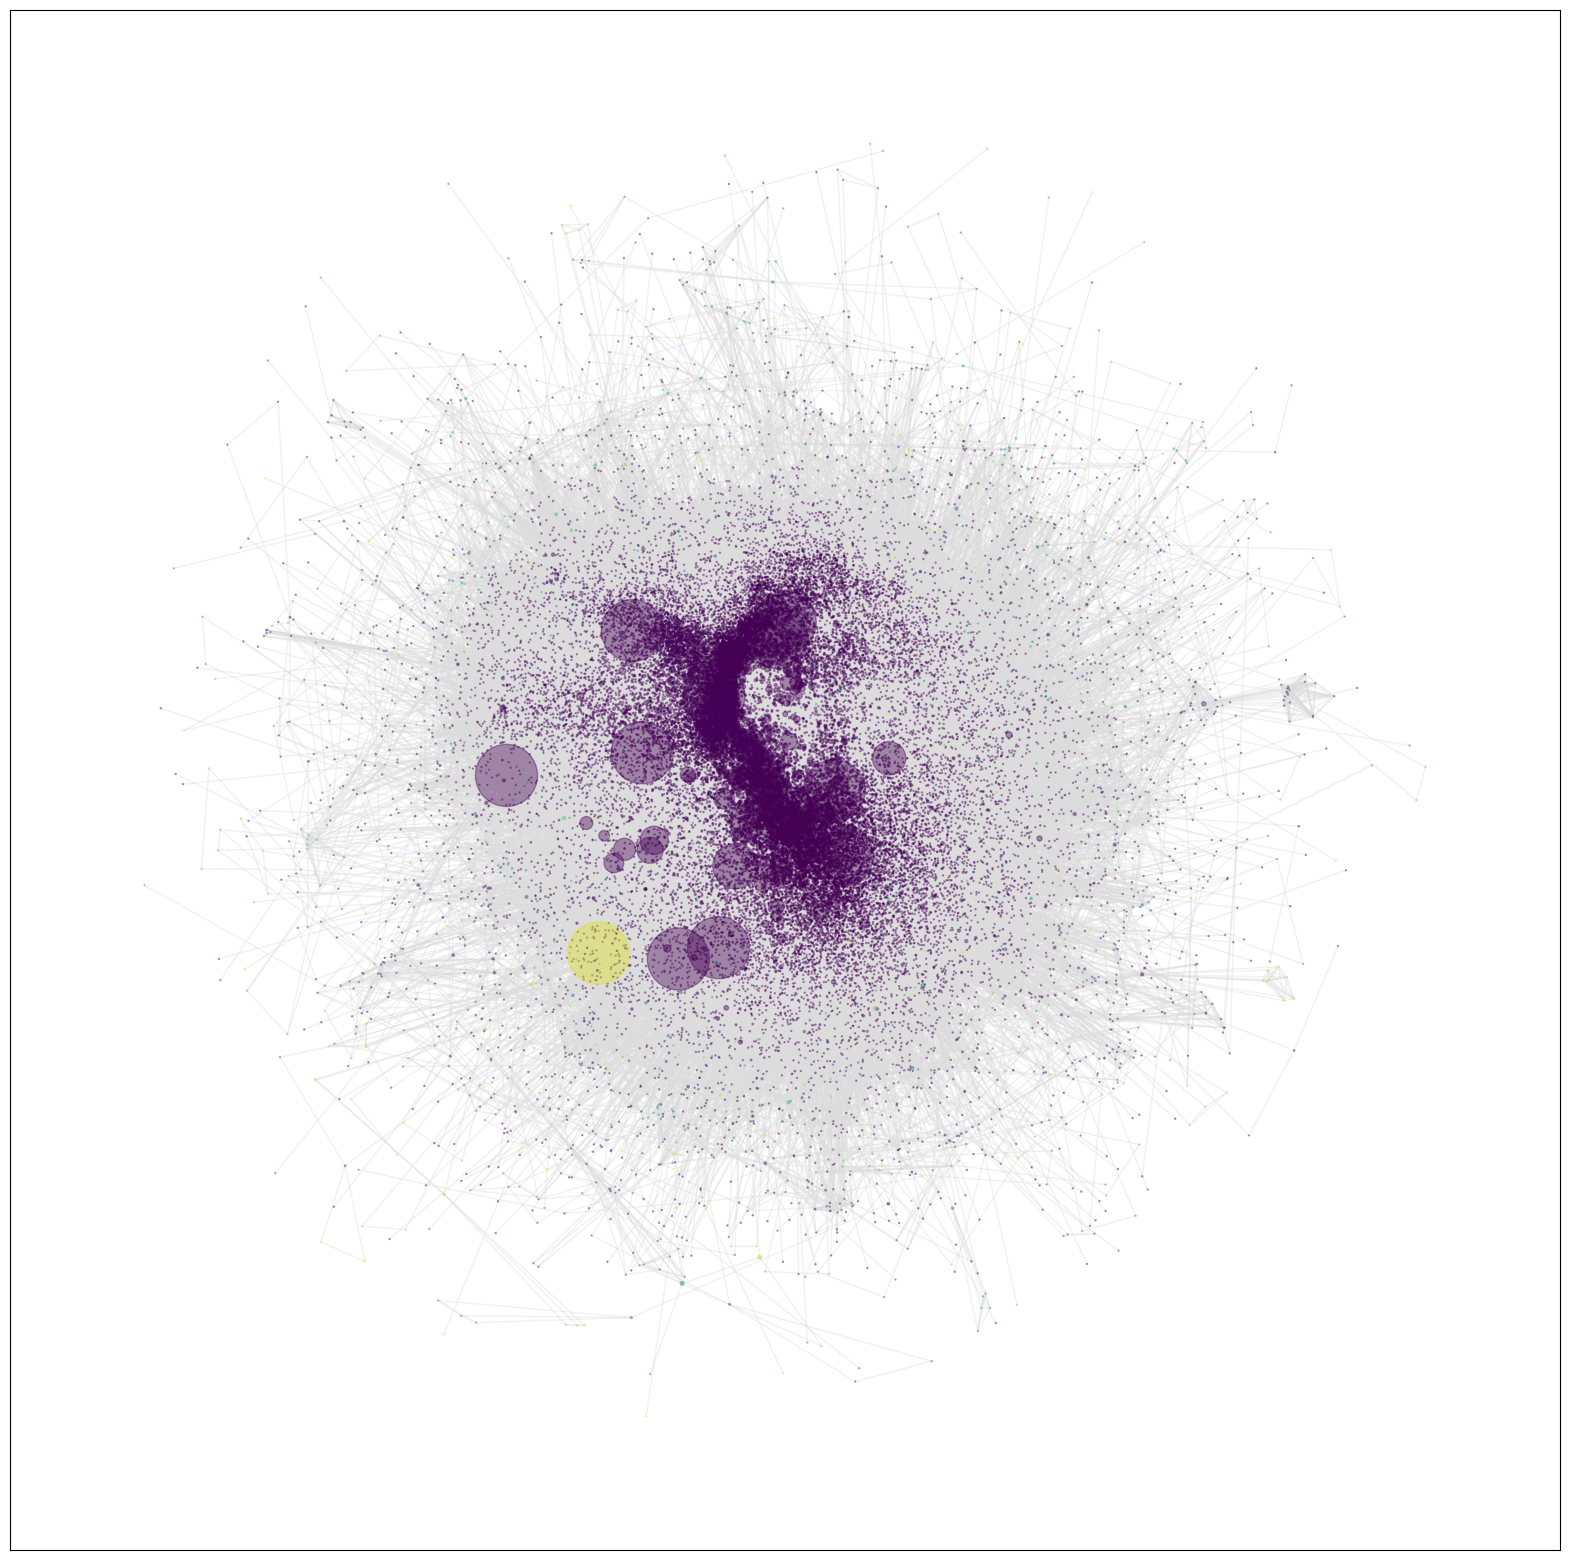

In [25]:
draw_network_largest_component(G_movie)

In [ ]:
def draw_network(G):
    """绘制网络图"""
    lpc = nx.community.label_propagation_communities(G)
    community_index = {n: i for i, com in enumerate(lpc) for n in com}
    #### draw graph ####
    fig, ax = plt.subplots(figsize=(20, 20))
    pos = nx.spring_layout(G, k=0.15, seed=4572321)
    node_color = [community_index[n] for n in G]
    return nx.draw_networkx(
        G,
        pos=pos,
        with_labels=False,
        node_color=node_color,
        edge_color="gainsboro",
        node_size=1,
        alpha=0.4,
    )

In [ ]:
draw_network(G_pruned)

# 图特征